# 03 · Does a router trained once actually decay?

This is the load-bearing experiment. RollingBench §14.1 is explicit that everything else
is downstream of it: *"There is no published experiment in which a router is trained at
time T and evaluated at T plus three months against a pool that has moved... that belief
is the load-bearing assumption of this proposal."*

The replay is retrospective and cost nothing to run. RouterBench's eleven models carry
real announcement dates from March to December 2023, so calendar time is a real axis:
pick a cut-off, let the pool grow as it actually grew, and watch four policies diverge.

| arm | what it is |
|---|---|
| **frozen (A)** | fitted once at T, never updated, cannot select a model released after T |
| **rolling (B)** | absorbs each week's outcomes; new models arrive with a cold-start probe |
| **refit, no new models (B′)** | keeps learning, but is never given the new models |
| **best single** | one model, everything sent to it, re-selected weekly |

B′ is the arm that makes the study conclusive. Without it, a frozen router losing ground
could be explained by stale data or by missing models, and those call for entirely
different engineering.

In [1]:
import sys; sys.path.insert(0, "..")
from notebooks.nbhelp import load, table, pct, show, md, finding
import numpy as np, pandas as pd

In [2]:
st = load("staleness"); res = st["result"]; s = st["summary"]
md(f"Replay: {len(res['weeks'])} weeks × {res['config']['batch_items']} fresh items per week, "
   f"cut-off **{res['config']['cutoff']}**, pool growing {min(res['pool_size'])} → "
   f"{max(res['pool_size'])} models.")
for n in res["notes"]:
    print("·", n)

Replay: 26 weeks × 400 fresh items per week, cut-off **2023-08-01**, pool growing 5 → 11 models.

· quality/cost are RouterBench measured cells; no inference was run
· model release dates are public announcement dates (see catalog.ROUTERBENCH_POOL)
· item order is a fixed shuffle: the item distribution is held constant so divergence is attributable to the pool moving, not to workload drift


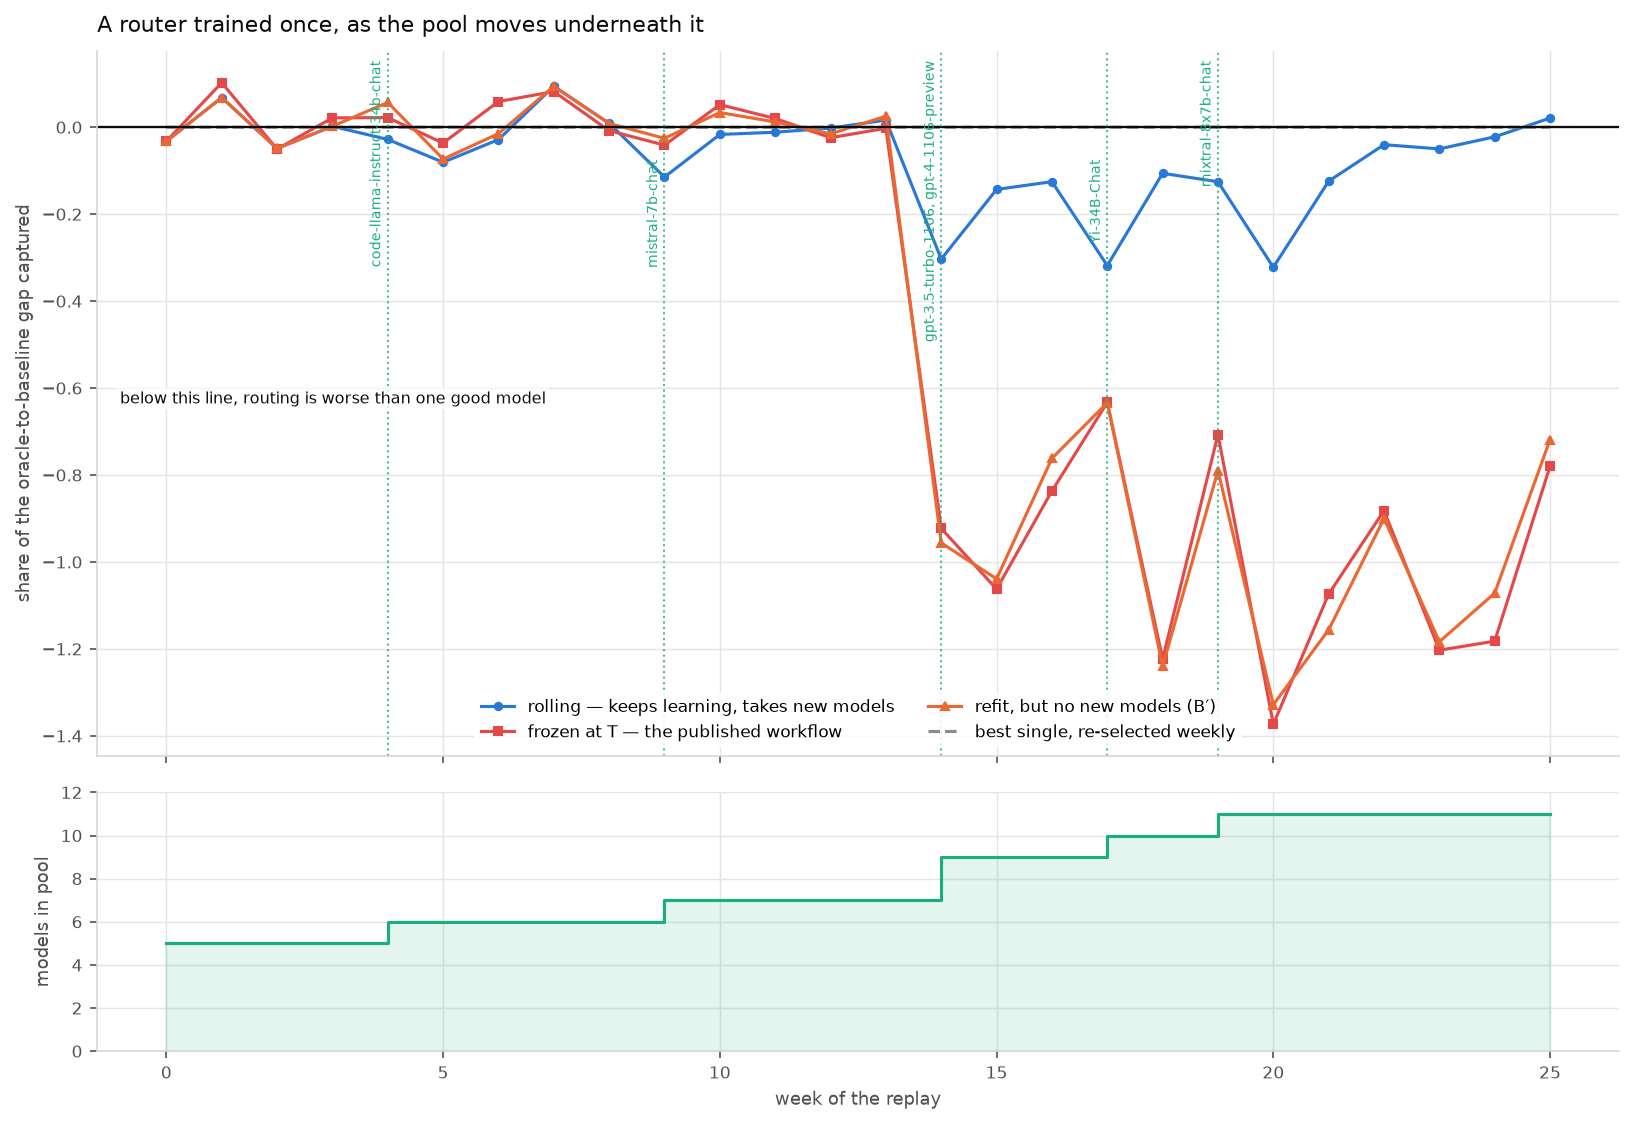

*Top: share of the oracle-to-baseline gap each arm captures, week by week. Green dotted lines mark real model releases. Bottom: the pool growing underneath all four arms.*

In [3]:
show("03_staleness",
     "Top: share of the oracle-to-baseline gap each arm captures, week by week. Green dotted "
     "lines mark real model releases. Bottom: the pool growing underneath all four arms.")

In [4]:
rows = []
for arm in ["frozen (A)", "rolling (B)", "refit, no new models (B')", "best single"]:
    a = res["arms"][arm]
    rows.append({"arm": arm,
                 "score, first 4 weeks": np.mean(a["score"][:4]),
                 "score, last 4 weeks": np.mean(a["score"][-4:]),
                 "change": np.mean(a["score"][-4:]) - np.mean(a["score"][:4]),
                 "quality, first 4": np.mean(a["quality"][:4]),
                 "quality, last 4": np.mean(a["quality"][-4:]),
                 "total spend $": np.sum(a["cost"])})
pd.DataFrame(rows).set_index("arm")

,"score, first 4 weeks","score, last 4 weeks",change,"quality, first 4","quality, last 4",total spend $
arm,,,,,,
frozen (A),0.0103,-1.0116,-1.0219,0.6368,0.6279,15.2626
rolling (B),-0.0027,-0.0227,-0.0201,0.6348,0.7767,21.8245
"refit, no new models (B')",-0.0027,-0.9683,-0.9656,0.6348,0.6341,15.4813
best single,0.0000,0.0000,0.0000,0.6354,0.7834,28.5366


In [5]:
md(f"""
The frozen router falls from **{s['frozen_start']:+.3f}** to **{s['frozen_end']:+.3f}** —
a decay of **{s['frozen_decay']:.3f}** — and crosses below the "one good model" line at
week **{s['week_crossed_below_best_single']}**, after which routing is actively worse than
not routing. The rolling router over the same period moves
**{s['rolling_start']:+.3f} → {s['rolling_end']:+.3f}**: no decay at all.

The gap between them widens from **{s['gap_first_half']:+.3f}** in the first half of the
replay to **{s['gap_second_half']:+.3f}** in the second.
""")
finding("supported",
        f"A router trained once decays materially — {s['frozen_decay']:.3f} over "
        f"{len(res['weeks'])} weeks — and ends up worse than sending everything to one "
        f"good model. §14.1's decision gate is passed: the premise survives, so the rest "
        f"of the system has a reason to exist.")


The frozen router falls from **+0.010** to **-1.012** —
a decay of **1.022** — and crosses below the "one good model" line at
week **5**, after which routing is actively worse than
not routing. The rolling router over the same period moves
**-0.003 → -0.023**: no decay at all.

The gap between them widens from **-0.027** in the first half of the
replay to **+0.788** in the second.


> **SUPPORTED** — A router trained once decays materially — 1.022 over 26 weeks — and ends up worse than sending everything to one good model. §14.1's decision gate is passed: the premise survives, so the rest of the system has a reason to exist.

## The part the proposal did not predict

Arm B′ separates the two causes, and the split is not what the framing of the proposal
suggests. RollingBench's title is *RollingBench* — the pitch is continuous re-evaluation,
fresher data, a benchmark that never goes stale. But:

In [6]:
tot = s["attribution_new_models"] + s["attribution_fresher_data"]
md(f"""
| cause | recovered score |
|---|---|
| access to models released after T | **{s['attribution_new_models']:+.3f}** ({s['attribution_new_models']/tot:.0%}) |
| fresher training data on the same models | {s['attribution_fresher_data']:+.3f} ({s['attribution_fresher_data']/tot:.0%}) |
""")
finding("new",
        f"Essentially all of the recoverable decay — {s['attribution_new_models']/tot:.0%} of it — "
        f"comes from being able to select models that did not exist at training time. "
        f"Continuously refitting on the same pool recovers almost nothing "
        f"({s['attribution_fresher_data']:+.3f}). The binding constraint is pool coverage and "
        f"cold start (FR-15's 24-hour onboarding), not evaluation freshness.")


| cause | recovered score |
|---|---|
| access to models released after T | **+0.778** (99%) |
| fresher training data on the same models | +0.010 (1%) |


> **NEW FINDING** — Essentially all of the recoverable decay — 99% of it — comes from being able to select models that did not exist at training time. Continuously refitting on the same pool recovers almost nothing (+0.010). The binding constraint is pool coverage and cold start (FR-15's 24-hour onboarding), not evaluation freshness.

That reorders the engineering. If the value is in onboarding new models fast rather than
in re-grading old ones daily, then the expensive daily sweep of the whole pool over fresh
items is buying the less valuable half, and the catalogue watcher plus the cold-start
probe are buying the more valuable half. Notebook 04 is about whether that cold start
actually works, and finds the hard case is exactly the one that matters here.

A caveat on scope, stated plainly: this replay holds the item distribution fixed, so it
measures decay from the pool moving and from data ageing. It does not measure workload
drift or contamination, which are two of the five causes §3.3 lists. Those need a corpus
with dated items, which RouterBench is not.

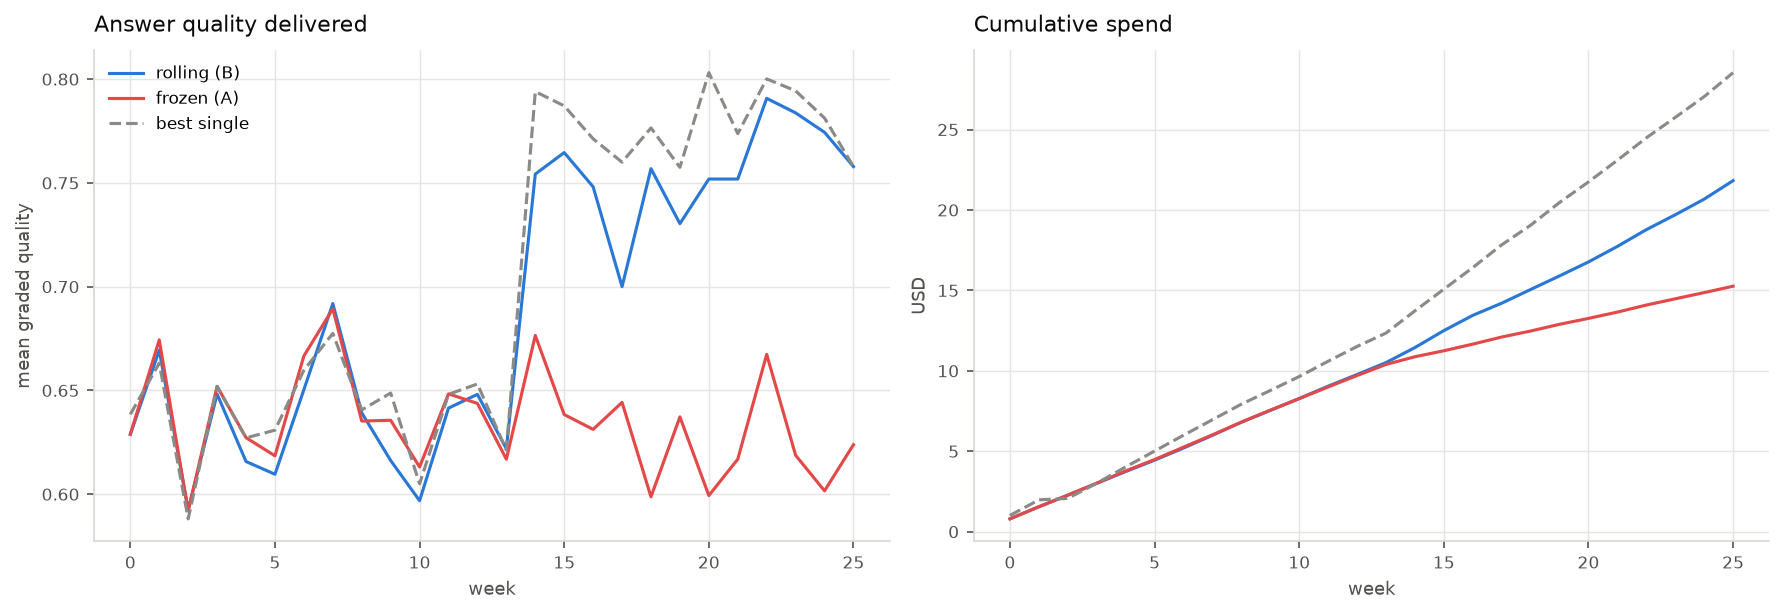

*The same divergence in units a customer would recognise: delivered answer quality, and cumulative spend.*

In [7]:
show("04_staleness_quality",
     "The same divergence in units a customer would recognise: delivered answer quality, "
     "and cumulative spend.")

In [8]:
new = res["new_models"]
md("### When each model arrived, and what happened\n\n" + "\n".join(
    f"- **week {w}** — {', '.join(m.split('/')[-1] for m in ms)}" for w, ms in sorted(new.items(), key=lambda kv: int(kv[0]))))

### When each model arrived, and what happened

- **week 4** — code-llama-instruct-34b-chat
- **week 9** — mistral-7b-chat
- **week 14** — gpt-3.5-turbo-1106, gpt-4-1106-preview
- **week 17** — Yi-34B-Chat
- **week 19** — mixtral-8x7b-chat